In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
crop_production = pd.read_csv("Data\\Crop_Production.csv")

crop_production.head()

,Unnamed: 0,State,District_Name,Year,Season,Crop,Area,Production
0,0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [4]:
# Data Info
print(crop_production.shape)
print('\n---------------------------------------------------------\n')

print(crop_production.info())
print('\n---------------------------------------------------------\n')

print(crop_production.describe())

(246091, 8)

---------------------------------------------------------

<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     246091 non-null  int64  
 1   State          246091 non-null  str    
 2   District_Name  246091 non-null  str    
 3   Year           246091 non-null  int64  
 4   Season         246091 non-null  str    
 5   Crop           246091 non-null  str    
 6   Area           246091 non-null  float64
 7   Production     242361 non-null  float64
dtypes: float64(2), int64(2), str(4)
memory usage: 23.9 MB
None

---------------------------------------------------------

          Unnamed: 0           Year          Area    Production
count  246091.000000  246091.000000  2.460910e+05  2.423610e+05
mean   123045.000000    2005.643018  1.200282e+04  5.825034e+05
std     71040.496885       4.952164  5.052340e+04  1.706581e+07

In [5]:
rainfall = pd.read_csv("Data\\Rainfall.csv")

rainfall.head()

,Unnamed: 0,State,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [6]:
# Data Info
print(rainfall.shape)
print('\n---------------------------------------------------------\n')

print(rainfall.info())
print('\n---------------------------------------------------------\n')

print(rainfall.describe())

(4188, 20)

---------------------------------------------------------

<class 'pandas.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  4188 non-null   int64  
 1   State       4188 non-null   str    
 2   Year        4188 non-null   int64  
 3   JAN         4184 non-null   float64
 4   FEB         4185 non-null   float64
 5   MAR         4182 non-null   float64
 6   APR         4184 non-null   float64
 7   MAY         4185 non-null   float64
 8   JUN         4183 non-null   float64
 9   JUL         4181 non-null   float64
 10  AUG         4184 non-null   float64
 11  SEP         4182 non-null   float64
 12  OCT         4181 non-null   float64
 13  NOV         4177 non-null   float64
 14  DEC         4178 non-null   float64
 15  ANNUAL      4162 non-null   float64
 16  JF          4182 non-null   float64
 17  MAM         4179 non-null   float64
 18  JJAS    

In [7]:
# Rename Columns (Fix Inconsistency in columns)
crop_production.rename(columns={
    'State_Name': 'State',
    'Crop_Year': 'Year'
}, inplace=True)

rainfall.rename(columns={
    'SUBDIVISION': 'State',
    'YEAR': 'Year'
}, inplace=True)

In [8]:
# Merged Crop + Rainfall Data
df = pd.merge(crop_production,rainfall,on=['State', 'Year'],how='inner')
df = df.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
df.head()

,State,District_Name,Year,Season,Crop,Area,Production,JAN,FEB,MAR,...,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Arunachal Pradesh,ANJAW,2004,Kharif,Maize,2453.0,2674.0,38.0,39.1,175.5,...,243.0,278.5,184.8,5.6,15.2,2545.7,77.1,684.3,1578.7,205.6
1,Arunachal Pradesh,ANJAW,2004,Kharif,Rice,3342.0,1914.0,38.0,39.1,175.5,...,243.0,278.5,184.8,5.6,15.2,2545.7,77.1,684.3,1578.7,205.6
2,Arunachal Pradesh,ANJAW,2004,Kharif,Small millets,532.0,495.0,38.0,39.1,175.5,...,243.0,278.5,184.8,5.6,15.2,2545.7,77.1,684.3,1578.7,205.6
3,Arunachal Pradesh,ANJAW,2004,Rabi,Wheat,30.0,60.0,38.0,39.1,175.5,...,243.0,278.5,184.8,5.6,15.2,2545.7,77.1,684.3,1578.7,205.6
4,Arunachal Pradesh,ANJAW,2004,Whole Year,Dry chillies,13.0,18.0,38.0,39.1,175.5,...,243.0,278.5,184.8,5.6,15.2,2545.7,77.1,684.3,1578.7,205.6


In [9]:
# Data Info
print(df.shape)
print('\n---------------------------------------------------------\n')

print(df.info())
print('\n---------------------------------------------------------\n')

print(df.describe())

(61777, 24)

---------------------------------------------------------

<class 'pandas.DataFrame'>
RangeIndex: 61777 entries, 0 to 61776
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State          61777 non-null  str    
 1   District_Name  61777 non-null  str    
 2   Year           61777 non-null  int64  
 3   Season         61777 non-null  str    
 4   Crop           61777 non-null  str    
 5   Area           61777 non-null  float64
 6   Production     60746 non-null  float64
 7   JAN            61777 non-null  float64
 8   FEB            61777 non-null  float64
 9   MAR            61777 non-null  float64
 10  APR            61777 non-null  float64
 11  MAY            61777 non-null  float64
 12  JUN            61777 non-null  float64
 13  JUL            61777 non-null  float64
 14  AUG            61777 non-null  float64
 15  SEP            61777 non-null  float64
 16  OCT            61777 non-null  fl

               Year           Area    Production           JAN           FEB  \
count  61777.000000   61777.000000  6.074600e+04  61777.000000  61777.000000   
mean    2005.694838    8229.529931  1.830209e+06     15.473403     23.935860   
std        4.870558   29798.504313  3.215227e+07     21.936571     34.390007   
min     1997.000000       0.040000  0.000000e+00      0.000000      0.000000   
25%     2002.000000      59.000000  6.500000e+01      2.400000      2.700000   
50%     2006.000000     451.000000  5.630000e+02      7.700000     11.300000   
75%     2010.000000    2920.000000  4.703000e+03     19.000000     30.300000   
max     2014.000000  545965.000000  1.250800e+09    147.800000    222.900000   

                MAR           APR           MAY           JUN           JUL  \
count  61777.000000  61777.000000  61777.000000  61777.000000  61777.000000   
mean      26.568537     41.257740     69.703585    180.232998    298.164880   
std       42.469912     54.286568     76.1

In [10]:
for col in df.select_dtypes(include=['str']).columns:
    print(f'{col} : \n {sorted(df[col].unique())}')

State : 
 ['Arunachal Pradesh', 'Bihar', 'Chhattisgarh', 'Himachal Pradesh', 'Jharkhand', 'Kerala', 'Punjab', 'Tamil Nadu', 'Uttarakhand']
District_Name : 
 ['ALAPPUZHA', 'ALMORA', 'AMRITSAR', 'ANJAW', 'ARARIA', 'ARIYALUR', 'ARWAL', 'AURANGABAD', 'BAGESHWAR', 'BALOD', 'BALODA BAZAR', 'BALRAMPUR', 'BANKA', 'BARNALA', 'BASTAR', 'BATHINDA', 'BEGUSARAI', 'BEMETARA', 'BHAGALPUR', 'BHOJPUR', 'BIJAPUR', 'BILASPUR', 'BOKARO', 'BUXAR', 'CHAMBA', 'CHAMOLI', 'CHAMPAWAT', 'CHANGLANG', 'CHATRA', 'COIMBATORE', 'CUDDALORE', 'DANTEWADA', 'DARBHANGA', 'DEHRADUN', 'DEOGHAR', 'DHAMTARI', 'DHANBAD', 'DHARMAPURI', 'DIBANG VALLEY', 'DINDIGUL', 'DUMKA', 'DURG', 'EAST KAMENG', 'EAST SIANG', 'EAST SINGHBUM', 'ERNAKULAM', 'ERODE', 'FARIDKOT', 'FATEHGARH SAHIB', 'FAZILKA', 'FIROZEPUR', 'GARHWA', 'GARIYABAND', 'GAYA', 'GIRIDIH', 'GODDA', 'GOPALGANJ', 'GUMLA', 'GURDASPUR', 'HAMIRPUR', 'HARIDWAR', 'HAZARIBAGH', 'HOSHIARPUR', 'IDUKKI', 'JALANDHAR', 'JAMTARA', 'JAMUI', 'JANJGIR-CHAMPA', 'JASHPUR', 'JEHANABAD', 'KABIR

In [11]:
df['Season'] = df['Season'].str.strip()

In [12]:
for col in df.select_dtypes(include=['str']).columns:
    print(f'{col} : \n {sorted(df[col].unique())}')

State : 
 ['Arunachal Pradesh', 'Bihar', 'Chhattisgarh', 'Himachal Pradesh', 'Jharkhand', 'Kerala', 'Punjab', 'Tamil Nadu', 'Uttarakhand']
District_Name : 
 ['ALAPPUZHA', 'ALMORA', 'AMRITSAR', 'ANJAW', 'ARARIA', 'ARIYALUR', 'ARWAL', 'AURANGABAD', 'BAGESHWAR', 'BALOD', 'BALODA BAZAR', 'BALRAMPUR', 'BANKA', 'BARNALA', 'BASTAR', 'BATHINDA', 'BEGUSARAI', 'BEMETARA', 'BHAGALPUR', 'BHOJPUR', 'BIJAPUR', 'BILASPUR', 'BOKARO', 'BUXAR', 'CHAMBA', 'CHAMOLI', 'CHAMPAWAT', 'CHANGLANG', 'CHATRA', 'COIMBATORE', 'CUDDALORE', 'DANTEWADA', 'DARBHANGA', 'DEHRADUN', 'DEOGHAR', 'DHAMTARI', 'DHANBAD', 'DHARMAPURI', 'DIBANG VALLEY', 'DINDIGUL', 'DUMKA', 'DURG', 'EAST KAMENG', 'EAST SIANG', 'EAST SINGHBUM', 'ERNAKULAM', 'ERODE', 'FARIDKOT', 'FATEHGARH SAHIB', 'FAZILKA', 'FIROZEPUR', 'GARHWA', 'GARIYABAND', 'GAYA', 'GIRIDIH', 'GODDA', 'GOPALGANJ', 'GUMLA', 'GURDASPUR', 'HAMIRPUR', 'HARIDWAR', 'HAZARIBAGH', 'HOSHIARPUR', 'IDUKKI', 'JALANDHAR', 'JAMTARA', 'JAMUI', 'JANJGIR-CHAMPA', 'JASHPUR', 'JEHANABAD', 'KABIR

In [13]:
# Checking Null Values :-
df.isnull().sum()

State               0
District_Name       0
Year                0
Season              0
Crop                0
Area                0
Production       1031
JAN                 0
FEB                 0
MAR                 0
APR                 0
MAY                 0
JUN                 0
JUL                 0
AUG                 0
SEP                 0
OCT                 0
NOV                 0
DEC                 0
ANNUAL              0
JF                  0
MAM                 0
JJAS                0
OND                 0
dtype: int64

In [14]:
# Dealing With Null Values
df['Production'] = df['Production'].fillna(df['Production'].mean())

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
# Checking Duplicated Values :-
df.duplicated().sum()

np.int64(0)

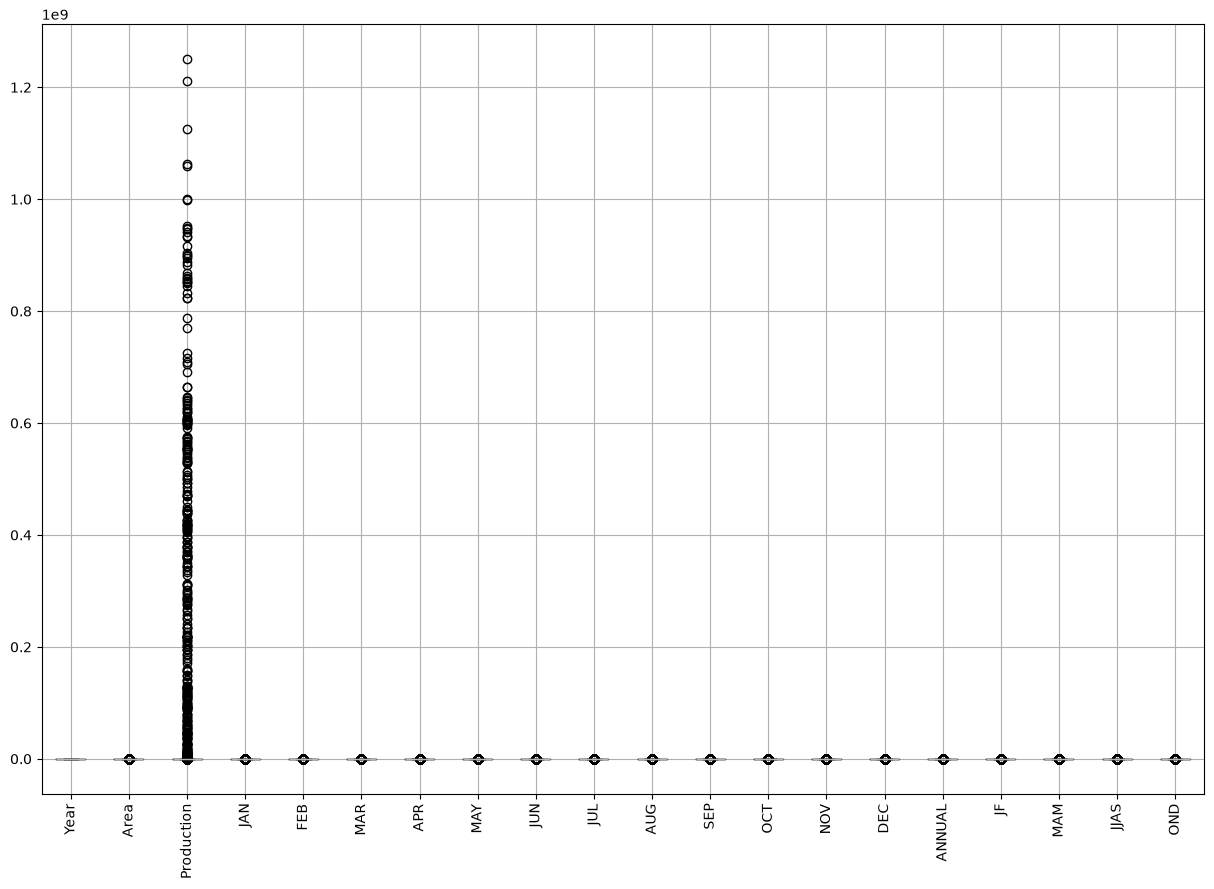

In [17]:
# checking outliers :-
plt.figure(figsize=(15,10))
df.boxplot()
plt.xticks(rotation=90)
plt.show()

In [18]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outlier_columns = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    if len(outliers) > 0:
        print(f"{col} → Outliers present ({len(outliers)} rows)")
        outlier_columns.append(col)
    else:
        print(f"{col} → No outliers")
    

Year → No outliers
Area → Outliers present (9580 rows)
Production → Outliers present (11293 rows)
JAN → Outliers present (5393 rows)
FEB → Outliers present (5227 rows)
MAR → Outliers present (7960 rows)
APR → Outliers present (8433 rows)
MAY → Outliers present (4701 rows)
JUN → Outliers present (3487 rows)
JUL → Outliers present (497 rows)
AUG → Outliers present (436 rows)
SEP → Outliers present (923 rows)
OCT → Outliers present (1822 rows)
NOV → Outliers present (9731 rows)
DEC → Outliers present (5402 rows)
ANNUAL → Outliers present (6859 rows)
JF → Outliers present (5395 rows)
MAM → Outliers present (6289 rows)
JJAS → Outliers present (886 rows)
OND → Outliers present (10829 rows)


In [19]:
print(outlier_columns)

['Area', 'Production', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JF', 'MAM', 'JJAS', 'OND']


In [20]:
# List of columns that contain outliers
outlier_columns = ['Area', 'Production', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JF', 'MAM', 'JJAS', 'OND']

# Clip outliers in each of these columns
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("All outlier columns clipped successfully!")


All outlier columns clipped successfully!


In [42]:
# Export final data
df.to_csv("Data/Crop_Production_Data.csv", index= False)

In [22]:
rain_yearly = df.groupby(['Year', 'State'])['ANNUAL'].mean().reset_index()
rain_yearly

,Year,State,ANNUAL
0,1997,Arunachal Pradesh,2017.75
1,1997,Bihar,1303.70
2,1997,Kerala,2017.75
3,1997,Punjab,690.10
4,1997,Tamil Nadu,950.50
...,...,...,...
133,2014,Bihar,1061.00
134,2014,Chhattisgarh,1278.70
135,2014,Kerala,2017.75
136,2014,Punjab,382.70


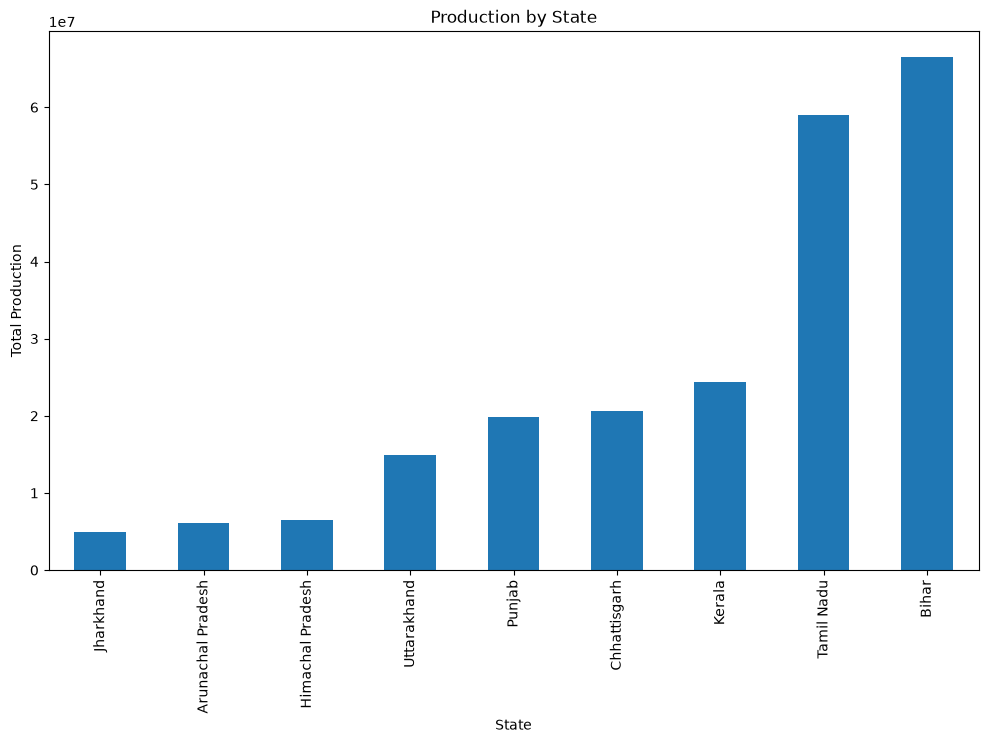

Conclusion: Bihar show higher production among all the states.


In [23]:
# Bar Chart – State-wise Production
state_prod = df.groupby("State")["Production"].sum().sort_values()

plt.figure(figsize=(12,7))
state_prod.plot(kind='bar')
plt.title("Production by State")
plt.ylabel("Total Production")
plt.xticks(rotation=90)
plt.show()

print("Conclusion: Bihar show higher production among all the states.")


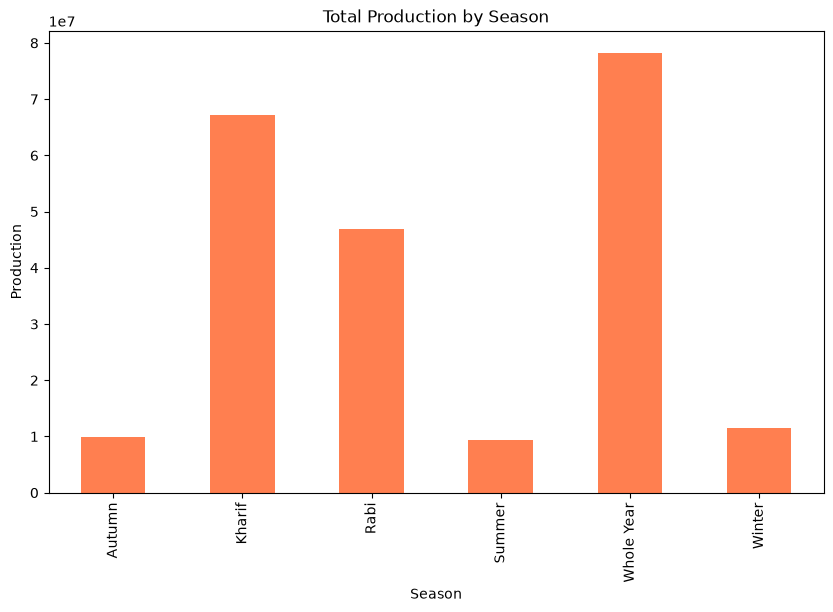

Conclusion: Whole Year season contribute most to India’s production.


In [24]:
# Stacked Bar – Crop Production by Season
season_prod = df.groupby("Season")["Production"].sum()

plt.figure(figsize=(10,6))
season_prod.plot(kind='bar', color="coral")
plt.title("Total Production by Season")
plt.ylabel("Production")
plt.show()

print("Conclusion: Whole Year season contribute most to India’s production.")


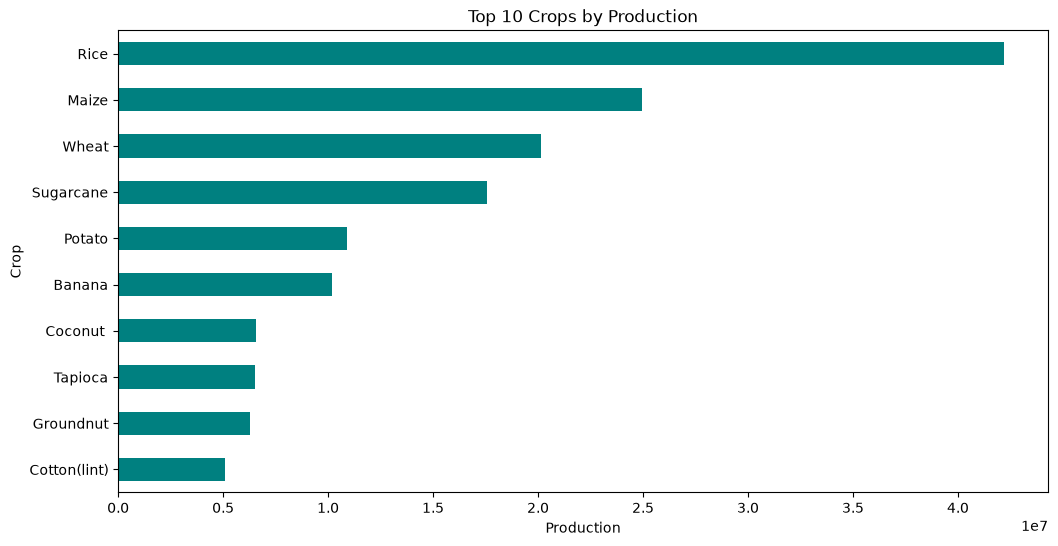

Conclusion: These crops play the biggest role in India’s agricultural economy.


In [25]:
# Bar Chart – Top 10 Crops by Production
top_crops = df.groupby("Crop")["Production"].sum().sort_values().tail(10)

plt.figure(figsize=(12,6))
top_crops.plot(kind='barh', color="teal")
plt.title("Top 10 Crops by Production")
plt.xlabel("Production")
plt.show()

print('Conclusion: These crops play the biggest role in India’s agricultural economy.')

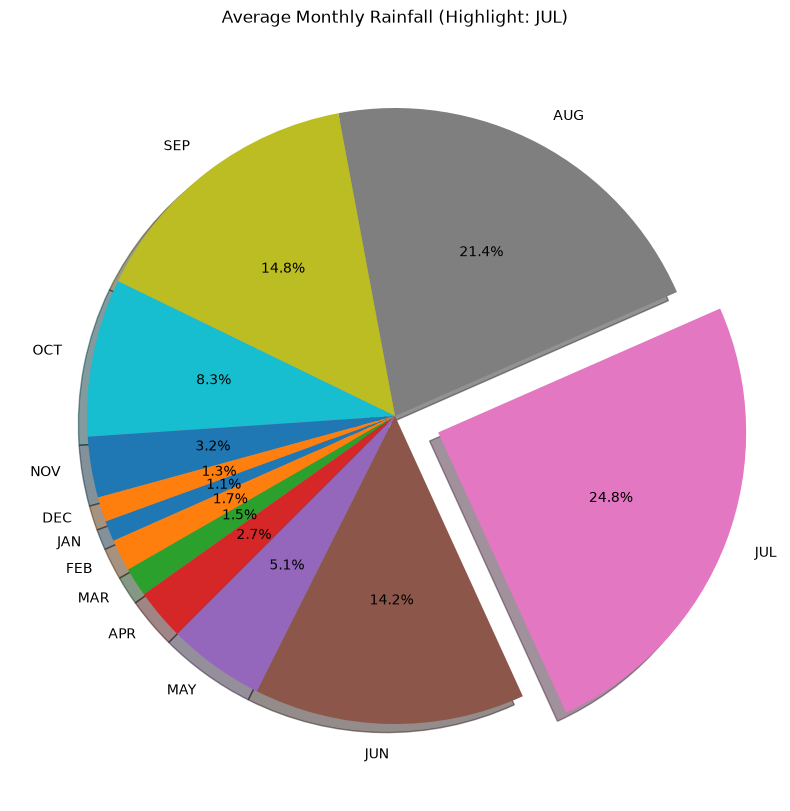

Conclusion: India receives maximum rainfall in monsoon months (Jun–Oct).


In [26]:
# Pie Chart – Average Monthly Rainfall
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG',
          'SEP', 'OCT', 'NOV', 'DEC']

mean_vals = df[months].mean()
max_month = mean_vals.idxmax()

explode = [0.15 if m == max_month else 0 for m in months]

plt.figure(figsize=(10,10))
plt.pie(mean_vals, labels=months, autopct='%1.1f%%', explode=explode, shadow=True, startangle=200)

plt.title(f"Average Monthly Rainfall (Highlight: {max_month})")
plt.show()

print('Conclusion: India receives maximum rainfall in monsoon months (Jun–Oct).')


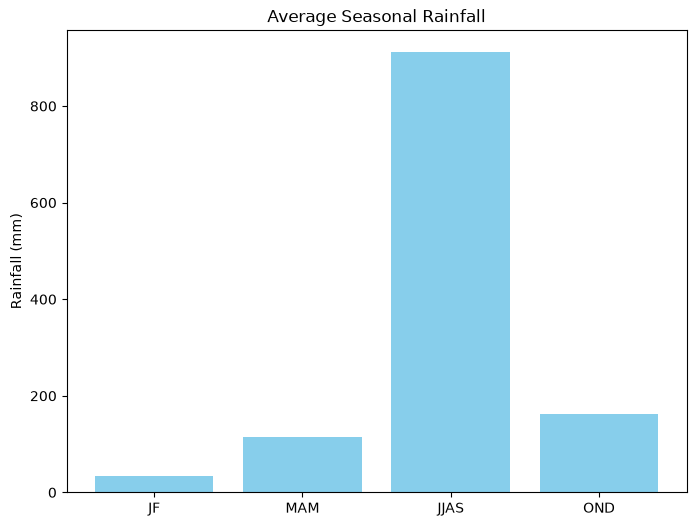

Conclusion: Monsoon season dominates India's rainfall pattern.


In [27]:

# Bar Chart – Seasonal Rainfall (JF, MAM, JJAS, OND) :-
#  winter (JF),  Pre-monsoon (MAM),  Southwest summer monsoon (JJAS), and  Post-monsoon (OND) 

seasons = ['JF','MAM','JJAS','OND']
plt.figure(figsize=(8,6))
plt.bar(seasons, df[seasons].mean(), color='skyblue')
plt.title("Average Seasonal Rainfall")
plt.ylabel("Rainfall (mm)")
plt.show()

print("Conclusion: Monsoon season dominates India's rainfall pattern.")

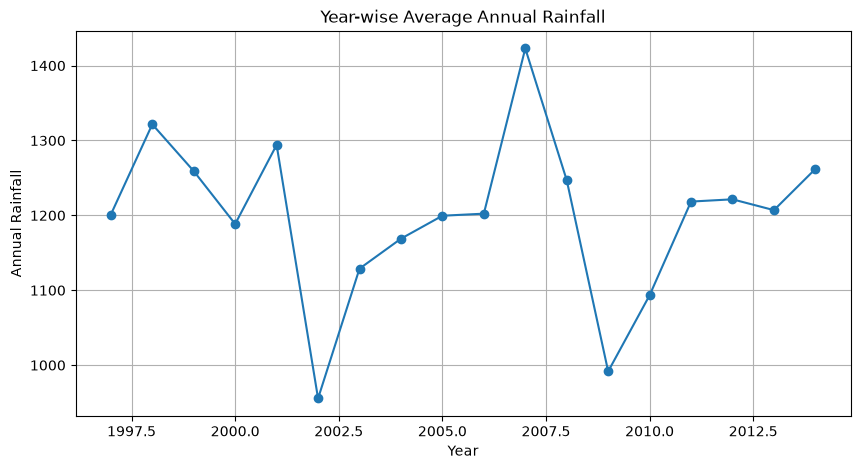

Conclusion: Rainfall fluctuates over years


In [28]:
# Annual Rainfall Trend (Year vs Rainfall)

yearly_rain = df.groupby("Year")["ANNUAL"].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_rain.index, yearly_rain.values, marker='o')
plt.title("Year-wise Average Annual Rainfall")
plt.xlabel("Year")
plt.ylabel("Annual Rainfall")
plt.grid(True)
plt.show()

print('Conclusion: Rainfall fluctuates over years')

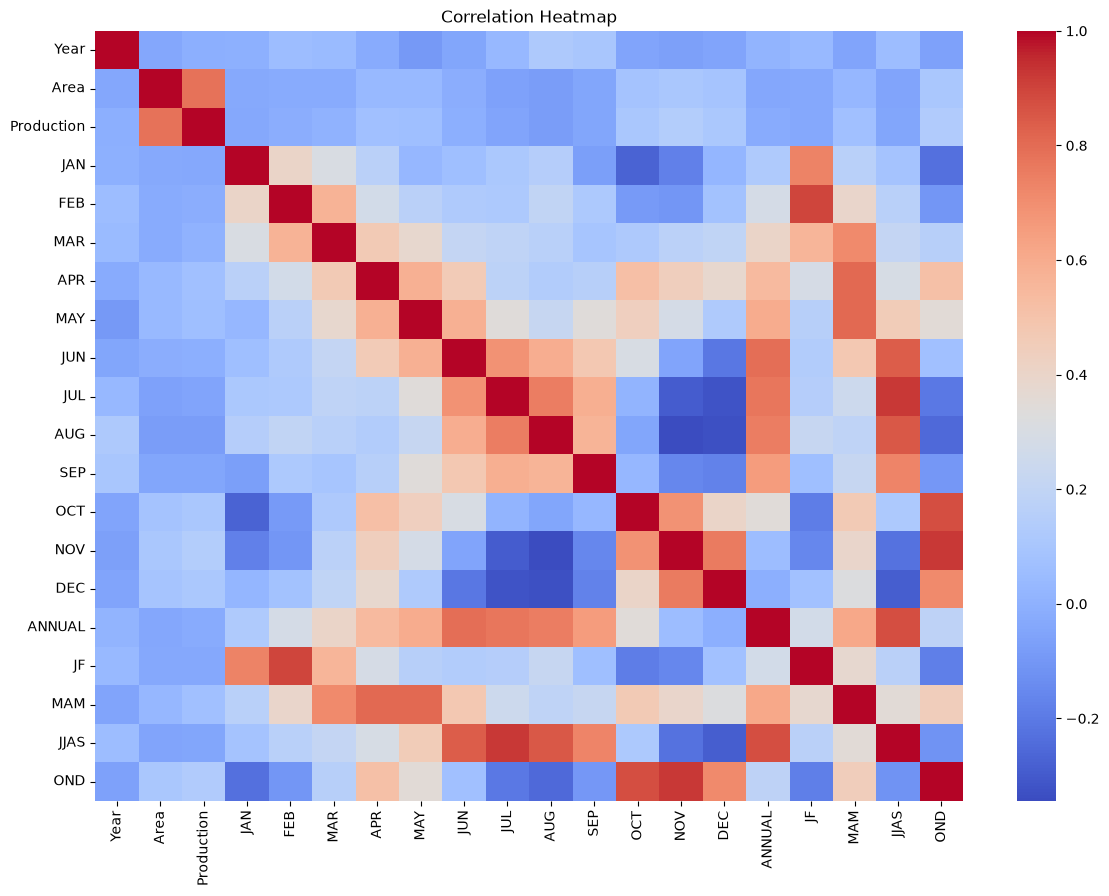

Conclusion: Certain rainfall months influence crop production more than others.


In [29]:
# Correlation Heatmap (Production vs Rainfall)
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

print("Conclusion: Certain rainfall months influence crop production more than others.")

<class 'pandas.DataFrame'>
RangeIndex: 61777 entries, 0 to 61776
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     61777 non-null  int64  
 1   State          61777 non-null  str    
 2   District_Name  61777 non-null  str    
 3   Year           61777 non-null  int64  
 4   Season         61777 non-null  str    
 5   Crop           61777 non-null  str    
 6   Area           61777 non-null  float64
 7   Production     61777 non-null  float64
 8   JAN            61777 non-null  float64
 9   FEB            61777 non-null  float64
 10  MAR            61777 non-null  float64
 11  APR            61777 non-null  float64
 12  MAY            61777 non-null  float64
 13  JUN            61777 non-null  float64
 14  JUL            61777 non-null  float64
 15  AUG            61777 non-null  float64
 16  SEP            61777 non-null  float64
 17  OCT            61777 non-null  float64
 18  NOV            61

# Model Building

XGBOOST REGRESSION RESULTS
Train R² Score : 0.9424
Test R² Score  : 0.9115
MAE            : 755.52
RMSE           : 1528.00

Model Analysis
✅ Good Fit : No Significant Overfitting


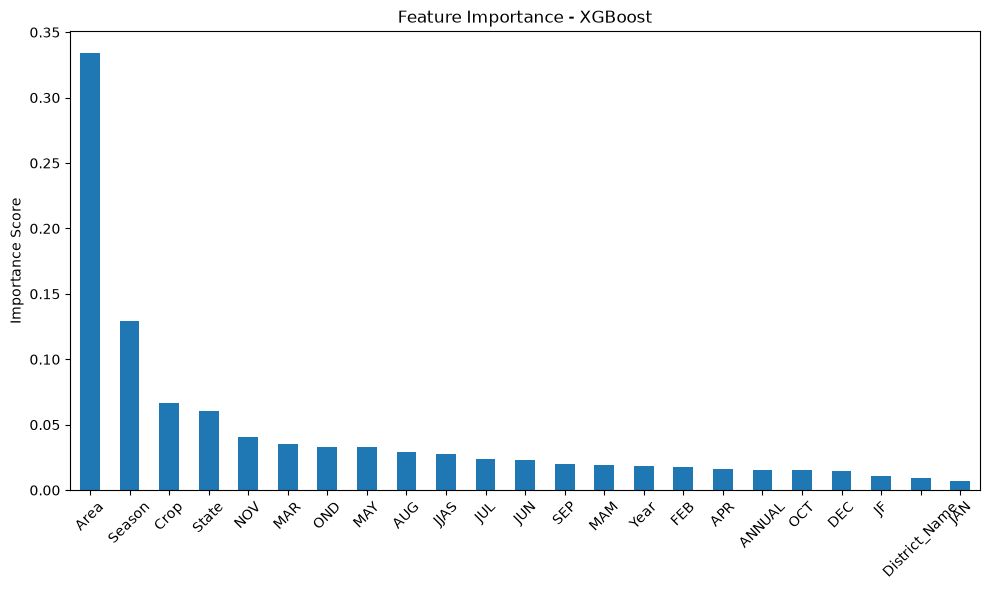

In [ ]:
# ==========================================
# Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ==========================================
# Load Dataset
# ==========================================
df = pd.read_csv("Data/Crop_Production_Data.csv")

# ==========================================
# Features and Target
# ==========================================
x = df.drop(['Production', 'Unnamed: 0'], axis=1)
y = df['Production']

# ==========================================
# Label Encoding
# ==========================================
categorical_cols = df.select_dtypes(include=['str']).columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])

    encoders[col] = le

# ==========================================
# Train Test Split
# ==========================================
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

# ==========================================
# XGBoost Model
# ==========================================
xgb = XGBRegressor()

# Train Model
xgb.fit(x_train, y_train)

# ==========================================
# Predictions
# ==========================================
y_pred_train = xgb.predict(x_train)
y_pred_test = xgb.predict(x_test)

# ==========================================
# Evaluation Metrics
# ==========================================
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

mae = mean_absolute_error(y_test, y_pred_test)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_test)
)

# ==========================================
# Results
# ==========================================
print("="*40)
print("XGBOOST REGRESSION RESULTS")
print("="*40)

print(f"Train R² Score : {train_r2:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")
print(f"MAE            : {mae:.2f}")
print(f"RMSE           : {rmse:.2f}")

# ==========================================
# Overfitting Check
# ==========================================
print("\nModel Analysis")

if abs(train_r2 - test_r2) < 0.05:
    print("✅ Good Fit : No Significant Overfitting")

elif train_r2 > test_r2:
    print("⚠️ Warning : Model Overfitting")

else:
    print("⚠️ Model Underfitting")

# ==========================================
# Feature Importance
# ==========================================
importance = pd.Series(
    xgb.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title("Feature Importance - XGBoost")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [45]:
print("Mean : ", df['Production'].mean())
print("Median : ", df['Production'].median())

Mean :  3609.0834579212324
Median :  600.0


In [49]:
encoders

{'State': LabelEncoder(),
 'District_Name': LabelEncoder(),
 'Season': LabelEncoder(),
 'Crop': LabelEncoder()}

In [48]:
# ==========================================
# Save Model
# ==========================================
import joblib

joblib.dump(xgb, "Models/crop_production_model.pkl")

# Save Encoders
joblib.dump(encoders, "Models/label_encoders.pkl")


['Models/label_encoders.pkl']